h = 0.01
Average y value: 1.9104499370588535
Average error: 0.36856059023374593
y near x=15: 0.23143958278779136
Local error near x=15: 0.040935364208888436
h = 0.05
Average y value: 1.0172906088100433
Average error: 1.2587920561793158
y near x=15: 0.11986884462030582
Local error near x=15: 0.15250610237637396
h = 0.10
Average y value: 0.5364730912105312
Average error: 1.735210633185963
y near x=15: 0.05131833580208424
Local error near x=15: 0.22105661119459558
h = 0.15
Average y value: 0.31901576100321105
Average error: 1.9505472355337954
y near x=15: 0.020921338696345163
Local error near x=15: 0.25145360830033536
h = 0.20
Average y value: 0.20328640407141324
Average error: 2.0590033344672105
y near x=15: 0.007903260555351253
Local error near x=15: 0.26447168644132857
h = 0.25
Average y value: 0.13526275627440978
Average error: 2.130091211821083
y near x=15: 0.0026622902905731154
Local error near x=15: 0.26971265670610667
h = 0.30
Average y value: 0.09073753013010184
Average error: 2.

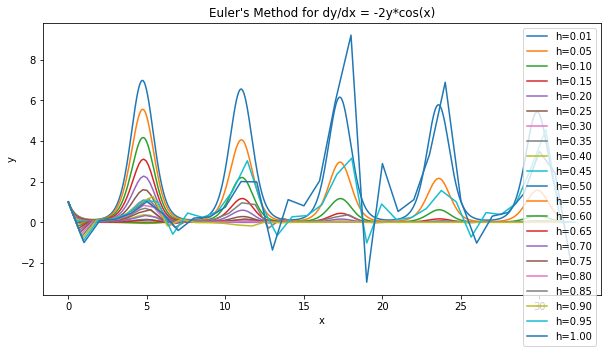

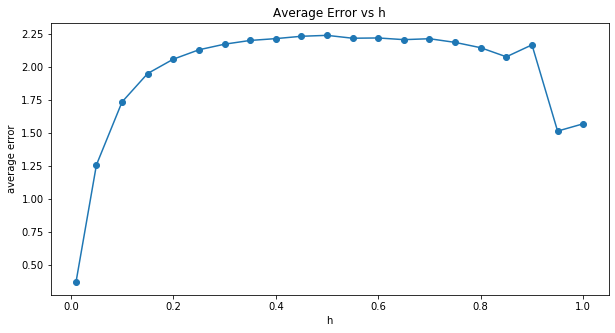

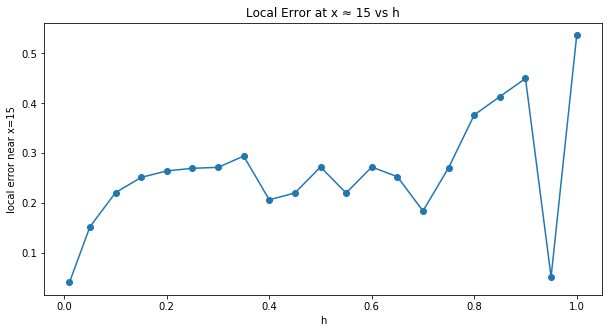

h = 0.1
Total Error: 0.5166555576322874
h = 0.5
Total Error: 0.581976705669783
h = 1.0
Total Error: 10.119202921776422
h = 1.5
Total Error: 126.03444519559521


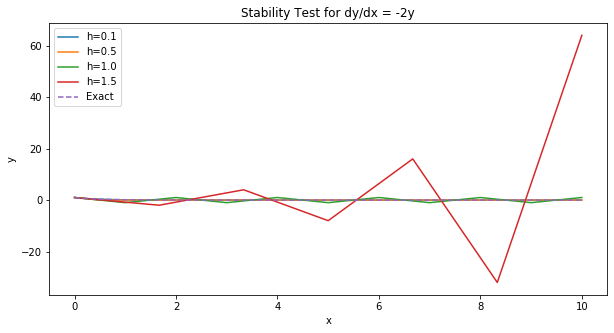

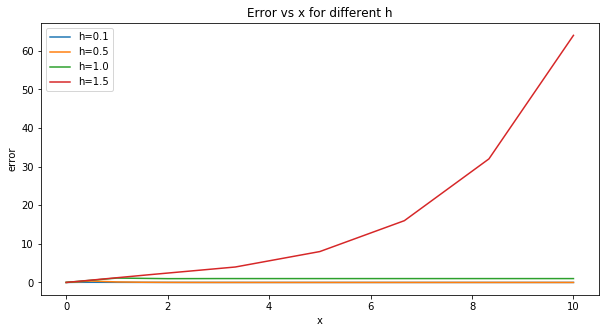

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

def exact1(x):
    return np.exp(-2*np.sin(x))

hs1 = [0.01, *np.arange(0.05, 1.05, 0.05)]
avg_y = []
avg_err = []
err_15 = []
y_15 = []

plt.figure(figsize=(10, 5))

for h in hs1:
    x_start, x_end = 0, 10*math.pi
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))

    y_values[0] = 1

    def f(x, y):
        return -2 * y * math.cos(x)

    for i in range(1, len(x_values)):
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        y_values[i] = y_n + h * f(x_n, y_n)

    y_exact = exact1(x_values)
    y_err = np.abs(y_exact - y_values)

    idx_15 = np.abs(x_values - 15).argmin()

    avg_y.append(np.mean(y_values))
    avg_err.append(np.mean(y_err))
    err_15.append(y_err[idx_15])
    y_15.append(y_values[idx_15])

    plt.plot(x_values, y_values, label=f"h={h:.2f}")

    print(f"h = {h:.2f}")
    print(f"Average y value: {np.mean(y_values)}")
    print(f"Average error: {np.mean(y_err)}")
    print(f"y near x=15: {y_values[idx_15]}")
    print(f"Local error near x=15: {y_err[idx_15]}")
    print("================================")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for dy/dx = -2y*cos(x)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hs1, avg_err, marker='o')
plt.xlabel("h")
plt.ylabel("average error")
plt.title("Average Error vs h")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hs1, err_15, marker='o')
plt.xlabel("h")
plt.ylabel("local error near x=15")
plt.title("Local Error at x ≈ 15 vs h")
plt.show()

def exact2(x):
    return np.exp(-2*x)

hs2 = [0.1, 0.5, 1.0, 1.5]
all_x = []
all_y = []
all_err = []

plt.figure(figsize=(10,5))

for h in hs2:
    x_start, x_end = 0, 10
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1

    def f(x, y):
        return -2 * y

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    y_exact = exact2(x_values)
    y_err = np.abs(y_exact - y_values)

    all_x.append(x_values)
    all_y.append(y_values)
    all_err.append(y_err)

    plt.plot(x_values, y_values, label=f"h={h}")

    print(f"h = {h}")
    print(f"Total Error: {sum(y_err)}")
    print("================================")

plt.plot(all_x[0], exact2(all_x[0]), linestyle='--', label="Exact")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Stability Test for dy/dx = -2y")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))

for i in range(len(hs2)):
    plt.plot(all_x[i], all_err[i], label=f"h={hs2[i]}")

plt.xlabel("x")
plt.ylabel("error")
plt.title("Error vs x for different h")
plt.legend()
plt.show()


"""
Eulers method is less accurate with a bigger step size. 
Bigger stepsize means more error accumulation. 
The smoother plots occur because of a smaller step size, due to
the accuracy of a smaller step size. The more blocky plots occur
due to a larger step size. 
"""